#Análisis de variables

In [1]:
import pandas as pd
ruta = "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/PUNTOS/Base de datos/Finales/Compilado.xlsx"

puntos = pd.read_excel(ruta, decimal=",")

In [2]:
import geopandas as gpd
menm = gpd.GeoDataFrame(puntos,
    geometry=gpd.points_from_xy(puntos.Longitud, puntos.Latitud),
    crs="EPSG:4326")

menm = menm.to_crs("EPSG:9377")
menm["x"] = menm.geometry.x
menm["y"] = menm.geometry.y
menm.head()

,ID,Tipo,Fecha,Latitud,Longitud,Sitio,Fuente,geometry,x,y
0,1,Flujo,1921-01-04,6.194158,-75.570134,*,SIMMA,POINT (4715686.99 2243131.235),4.715687e+06,2.243131e+06
1,2,Flujo,1921-03-03,6.196886,-75.565530,*,SIMMA,POINT (4716198.087 2243430.507),4.716198e+06,2.243431e+06
2,3,Flujo,1921-03-13,6.206115,-75.565556,*,SIMMA,POINT (4716200.15 2244451.32),4.716200e+06,2.244451e+06
3,4,Deslizamiento,1921-10-22,6.250551,-75.595250,*,SIMMA,POINT (4712937.395 2249382.418),4.712937e+06,2.249382e+06
4,5,Flujo,1923-06-16,6.230405,-75.614995,DE MOLINA,SIMMA,POINT (4710740.836 2247164.852),4.710741e+06,2.247165e+06


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib as mpl
from statsmodels.api import GLM, families


##Creación de variables

In [7]:
#Comunas de Medellín
comunas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="comuna")
comunas.head()

,COMUNA,SECTOR,NOMBRE,Shape_Leng,Shape_Area,geometry
0,16,6,BELEN,25221.690181,8.656577e+06,"MULTIPOLYGON (((4710667.231 2247452.276, 47106..."
1,01,1,POPULAR,10842.861523,3.138493e+06,"MULTIPOLYGON (((4717550.678 2253725.972, 47176..."
2,07,2,ROBLEDO,22884.517430,9.278984e+06,"MULTIPOLYGON (((4710155.808 2251946.829, 47101..."
3,04,1,ARANJUEZ,9970.020163,4.888780e+06,"MULTIPOLYGON (((4715653.558 2251610.707, 47156..."
4,05,2,CASTILLA,16196.158040,6.047489e+06,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [8]:
#Barrios de Medellín
barrios = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="Barrio")
barrios.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,geometry
0,Suburbano Potrera Miserenga,PALMITAS,10793.745904,1.112742e+06,"MULTIPOLYGON (((4702200.304 2261423.185, 47022..."
1,Piedras Blancas,SANTA ELENA,28242.883995,1.173412e+07,"MULTIPOLYGON (((4719822.945 2254827.749, 47198..."
2,Llanaditas,VILLA HERMOSA,3770.603451,2.638531e+05,"MULTIPOLYGON (((4719157.189 2250063.198, 47191..."
3,La Cuchilla,SAN CRISTOBAL,5659.422464,6.306618e+05,"MULTIPOLYGON (((4705777.892 2254965.265, 47057..."
4,Los Balsos No.1,EL POBLADO,6185.278317,1.426434e+06,"MULTIPOLYGON (((4717311.158 2242869.355, 47173..."


In [6]:
#Coberturas de Medellín
coberturas = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="cobertura")
coberturas.head()

,OBJECTID,gridcode,tipo,Shape_Leng,Shape_Le_1,Shape_Area,geometry
0,1,1,Territorios Artificializados,89.900856,8.651377e+06,8.417641e+07,"MULTIPOLYGON (((4704960.134 2239792.867, 47049..."
1,2,3,Bosques y Áreas Seminaturales,116.953861,1.474735e+07,2.319810e+08,"MULTIPOLYGON (((4704693.584 2239867.937, 47046..."
2,3,2,Territorios Agrícolas,226.705275,2.266805e+02,5.241470e+02,"MULTIPOLYGON (((4726569.934 2248473.025, 47265..."
3,4,2,Territorios Agrícolas,48.239084,4.823367e+01,1.045846e+02,"MULTIPOLYGON (((4726325.234 2248488.616, 47263..."
4,5,2,Territorios Agrícolas,102.165266,1.021541e+02,1.248471e+02,"MULTIPOLYGON (((4726445.272 2248334.446, 47264..."


In [9]:
#Geología de Medellín
geologia = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/menm_m.gpkg", layer="geologia")
geologia.head()

,SimboloUC,Descripcio,Edad,Shape_Area,geometry
0,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,9.812876e+06,"MULTIPOLYGON (((4708303.892 2241670.266, 47082..."
1,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,1.125072e+07,"MULTIPOLYGON (((4716717.4 2244807.552, 4716844..."
2,Q-ca,Abanicos aluviales y depósitos coluviales,Cuaternario,6.193436e+07,"MULTIPOLYGON (((4718511.947 2255337.695, 47185..."
3,DC1-Mmg,"Anfibolitas granatíferas, esquistos cuarzoseri...",Devónico-Mississipiano,4.420661e+06,"MULTIPOLYGON (((4722916.77 2244421.55, 4722629..."
4,T-Mag,"Gneises cuarzofeldespáticos, algunos con silli...",Triásico,1.125475e+06,"MULTIPOLYGON (((4719470.644 2241329.619, 47195..."


In [14]:
#Pendiente de Medellín
import rasterio

Pendiente = rasterio.open("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/SUPERFICIES/Pendiente.tif")

##Movimientos en masa por comuna

In [15]:
menm_comuna = gpd.sjoin(menm, comunas[["NOMBRE", "geometry"]], how="left", predicate="within")

conteo = (menm_comuna
    .groupby("NOMBRE")
    .size()
    .rename("Movimientos"))

###Creación de variables nuevas

In [16]:
gdf = comunas.copy()
gdf = gdf.merge(conteo, on="NOMBRE", how="left")

gdf["Movimientos"] = (gdf["Movimientos"].fillna(0).astype(int))
gdf["Area_km2"] = gdf.geometry.area / 1e6


In [17]:
gdf["Densidad"] = (gdf["Movimientos"] / gdf["Area_km2"])
gdf["Porc_area"] = (gdf["Area_km2"] / gdf["Area_km2"].sum()) * 100
gdf["Porc_mov"] = ( gdf["Movimientos"] / gdf["Movimientos"].sum()) * 100
gdf["I_concentracion"] = gdf["Porc_mov"] / gdf["Porc_area"]

In [18]:
resumen = (gdf[[ "NOMBRE", "Movimientos", "Area_km2", "Densidad",  "Porc_area", "Porc_mov", "I_concentracion"]]
    .sort_values("I_concentracion", ascending=False))

resumen

,NOMBRE,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion
1,POPULAR,267,3.138493,85.072680,0.832958,11.434690,13.727812
13,SANTA CRUZ,160,2.199504,72.743661,0.583750,6.852248,11.738332
18,VILLA HERMOSA,258,5.570153,46.318300,1.478322,11.049251,7.474185
12,SAN JAVIER,197,5.096967,38.650436,1.352738,8.436831,6.236855
7,MANRIQUE,187,4.881457,38.308236,1.295542,8.008565,6.181635
19,DOCE DE OCTUBRE,102,3.913373,26.064471,1.038612,4.368308,4.205912
3,ARANJUEZ,106,4.888780,21.682303,1.297485,4.539615,3.498780
0,BELEN,165,8.656577,19.060653,2.297461,7.066381,3.075736
15,BUENOS AIRES,106,5.981866,17.720223,1.587591,4.539615,2.859436
11,LA AMERICA,60,4.143343,14.481061,1.099646,2.569593,2.336746


In [19]:
from scipy import stats

y = gdf["Movimientos"].astype(int).values

media = y.mean()
varianza = y.var(ddof=1)
idisp = varianza / media

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"Índice de dispersión: {idisp:.2f}")

Media: 111.19
Varianza: 5233.26
Índice de dispersión: 47.07


##Movimientos en masa y geología

In [20]:
campo_geo = "SimboloUC"

geo = geologia.copy()

geo["Area_km2"] = geo.geometry.area / 1e6

area_geo = (geo
    .groupby(campo_geo)["Area_km2"]
    .sum()
    .reset_index())

In [21]:
menm_geo = gpd.sjoin(menm,  geo[[campo_geo, "geometry"]], how="left", predicate="within")

mov_geo = ( menm_geo.groupby(campo_geo)
.size()
.reset_index(name="Movimientos"))

###variables geología

In [22]:
resumen_geo = area_geo.merge(mov_geo, on=campo_geo, how="left")

resumen_geo["Movimientos"] = resumen_geo["Movimientos"].fillna(0).astype(int)
resumen_geo["Porc_area"] = (resumen_geo["Area_km2"] / resumen_geo["Area_km2"].sum()) * 100
resumen_geo["Porc_mov"] = ( resumen_geo["Movimientos"] / resumen_geo["Movimientos"].sum()) * 100
resumen_geo["Densidad"] = (resumen_geo["Movimientos"] / resumen_geo["Area_km2"])
resumen_geo["FR"] = (resumen_geo["Porc_mov"] / resumen_geo["Porc_area"])

resumen_geo = resumen_geo.sort_values("FR", ascending=False).round(2)

resumen_geo

,SimboloUC,Area_km2,Movimientos,Porc_area,Porc_mov,Densidad,FR
5,Q-ca,83.00,1325,22.18,56.75,15.96,2.56
10,T-Pu,41.28,428,11.03,18.33,10.37,1.66
2,K1-Pm,8.03,77,2.14,3.30,9.59,1.54
0,DC1-Mmg,4.42,26,1.18,1.11,5.88,0.94
4,Q-al,21.88,126,5.85,5.40,5.76,0.92
3,K2-Pi,79.30,291,21.19,12.46,3.67,0.59
9,T-Pf,15.51,26,4.14,1.11,1.68,0.27
8,T-Mmg,18.19,25,4.86,1.07,1.37,0.22
1,K1-Mmg,29.61,8,7.91,0.34,0.27,0.04
11,b5k4-VCm,18.25,1,4.88,0.04,0.05,0.01


##Movimientos en masa y coberturas

In [23]:
campo_cob = "tipo"

cob = coberturas.copy()
cob["Area_km2"] = cob.geometry.area / 1e6

area_cob = (cob.groupby(campo_cob)["Area_km2"].sum().reset_index())

###variables coberturas

In [24]:
menm_cob = gpd.sjoin(menm, cob[[campo_cob, "geometry"]], how="left", predicate="within")

mov_cob = (menm_cob
    .groupby(campo_cob)
    .size()
    .reset_index(name="Movimientos"))

In [25]:
resumen_cob = area_cob.merge(mov_cob, on=campo_cob, how="left")

resumen_cob["Movimientos"] = resumen_cob["Movimientos"].fillna(0).astype(int)
resumen_cob["Porc_area"] = (resumen_cob["Area_km2"] / resumen_cob["Area_km2"].sum()) * 100
resumen_cob["Porc_mov"] = (resumen_cob["Movimientos"] / resumen_cob["Movimientos"].sum()) * 100
resumen_cob["Densidad"] = (resumen_cob["Movimientos"] / resumen_cob["Area_km2"])
resumen_cob["FR"] = (resumen_cob["Porc_mov"] / resumen_cob["Porc_area"])

resumen_cob = resumen_cob.sort_values("FR", ascending=False).round(2)

resumen_cob

,tipo,Area_km2,Movimientos,Porc_area,Porc_mov,Densidad,FR
2,Territorios Artificializados,84.18,1497,22.36,64.11,17.78,2.87
0,Bosques y Áreas Seminaturales,245.25,726,65.16,31.09,2.96,0.48
1,Territorios Agrícolas,46.95,112,12.47,4.80,2.39,0.38


##Movimientos en masa y pendiente

In [ ]:
from rasterstats import zonal_stats

stats = zonal_stats(
    gdf,
    "/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/SUPERFICIES/Pendiente.tif",
    stats=["mean"],
    all_touched=True)

gdf["Pend_mean"] = [s["mean"] for s in stats]

##Creación de variables para modelos

In [ ]:
gdf["Area_km2"] = gdf.geometry.area / 1e6

In [ ]:
cob_art = coberturas[coberturas["tipo"] == "Territorios Artificializados"].copy()
cob_art = cob_art.dissolve()

In [ ]:
inter_art = gpd.overlay(
    gdf[["NOMBRE", "Area_km2", "geometry"]],
    cob_art[["geometry"]],
    how="intersection")

In [ ]:
inter_art["Area_art_km2"] = inter_art.geometry.area / 1e6

tabla_art = (inter_art
    .groupby("NOMBRE")["Area_art_km2"]
    .sum()
    .reset_index())

tabla_art = tabla_art.merge(
    gdf[["NOMBRE", "Area_km2"]],
    on="NOMBRE",
    how="left")

tabla_art["Porc_Artificial"] = (tabla_art["Area_art_km2"] / tabla_art["Area_km2"]) * 100

In [ ]:
gdf = gdf.merge(
    tabla_art[["NOMBRE", "Porc_Artificial"]],
    on="NOMBRE",
    how="left")

gdf["Porc_Artificial"] = gdf["Porc_Artificial"].fillna(0)

In [ ]:
def calcular_porcentaje_categoria_rapido(
    comunas,
    capa_variable,
    campo_comuna,
    campo_categoria,
    categoria,
    nombre_columna
):
    capa_filtrada = capa_variable[
        capa_variable[campo_categoria] == categoria
    ].copy()

    inter = gpd.overlay(
        comunas[[campo_comuna, "Area_km2", "geometry"]],
        capa_filtrada[[campo_categoria, "geometry"]],
        how="intersection"
    )

    inter["Area_inter_km2"] = inter.geometry.area / 1e6

    tabla = (
        inter
        .groupby(campo_comuna)["Area_inter_km2"]
        .sum()
        .reset_index()
    )

    tabla = tabla.merge(
        comunas[[campo_comuna, "Area_km2"]],
        on=campo_comuna,
        how="left"
    )

    tabla[nombre_columna] = (
        tabla["Area_inter_km2"] / tabla["Area_km2"]
    ) * 100

    comunas = comunas.merge(
        tabla[[campo_comuna, nombre_columna]],
        on=campo_comuna,
        how="left"
    )

    comunas[nombre_columna] = comunas[nombre_columna].fillna(0)

    return comunas

In [ ]:
gdf = calcular_porcentaje_categoria_rapido(
    gdf, geologia, "NOMBRE", "SimboloUC", "Q-ca", "Porc_Qca")

gdf = calcular_porcentaje_categoria_rapido(
    gdf, geologia, "NOMBRE", "SimboloUC", "T-Pu", "Porc_TPu")

In [ ]:
gdf[[ "NOMBRE",
        "Area_km2",
        "Porc_Artificial",
        "Porc_Qca",
        "Porc_TPu",
        "Alta_susceptibilidad","Pend_mean" ]].round(2)

KeyError: "['Alta_susceptibilidad'] not in index"

#Matriz espacial

In [ ]:
from libpysal import weights

w_queen = weights.Queen.from_dataframe(
    gdf, ids=gdf["NOMBRE"])

w_queen.transform = "r"

w_queen

In [ ]:
w_queen.neighbors['SANTA CRUZ']

In [ ]:
w_queen.cardinalities['SANTA CRUZ']

In [ ]:
queen_vec = pd.Series(w_queen.cardinalities)
queen_vec.head(21)

,0
BELEN,5
POPULAR,4
ROBLEDO,7
ARANJUEZ,7
CASTILLA,5
GUAYABAL,3
LAURELES,6
MANRIQUE,5
PALMITAS,2
ALTAVISTA,6


In [ ]:
gdf_idx = gdf.set_index("NOMBRE")

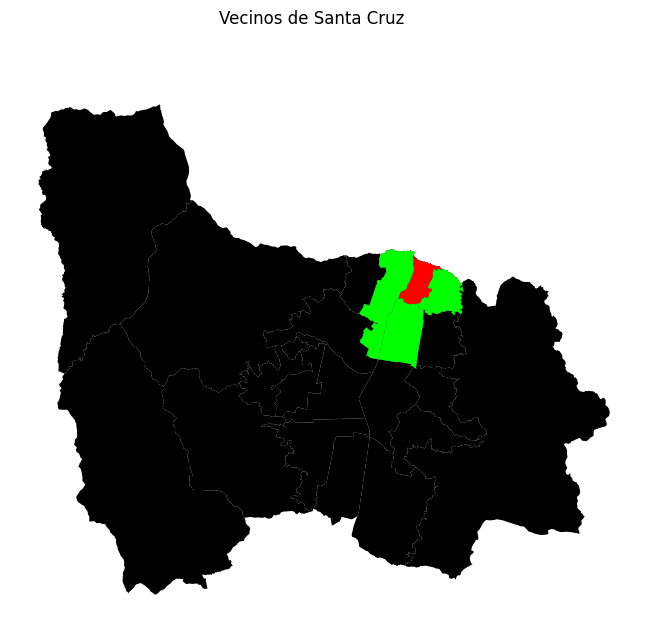

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 7))

gdf_idx.plot(ax=ax, facecolor='k', linewidth=5)

focus = gdf_idx.loc[['SANTA CRUZ'], ['geometry']]

focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

neighbors_list = list(w_queen['SANTA CRUZ'])

neis = gdf_idx.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

f.suptitle("Vecinos de Santa Cruz")

ax.set_axis_off()
plt.show()

In [ ]:
knn5 = weights.KNN.from_dataframe(gdf_idx, k=5)
knn5['SANTA CRUZ']

{np.str_('POPULAR'): 1.0,
 np.str_('CASTILLA'): 1.0,
 np.str_('ARANJUEZ'): 1.0,
 np.str_('DOCE DE OCTUBRE'): 1.0,
 np.str_('MANRIQUE'): 1.0}

In [ ]:
knn5_vec = pd.Series(knn5.cardinalities)
knn5_vec.head(10)

,0
BELEN,5
POPULAR,5
ROBLEDO,5
ARANJUEZ,5
CASTILLA,5
GUAYABAL,5
LAURELES,5
MANRIQUE,5
PALMITAS,5
ALTAVISTA,5


In [ ]:
w_dist5km = weights.DistanceBand.from_dataframe(gdf_idx, 5000)
w_dist5km['SANTA CRUZ']
w_dist5km.transform = "r"

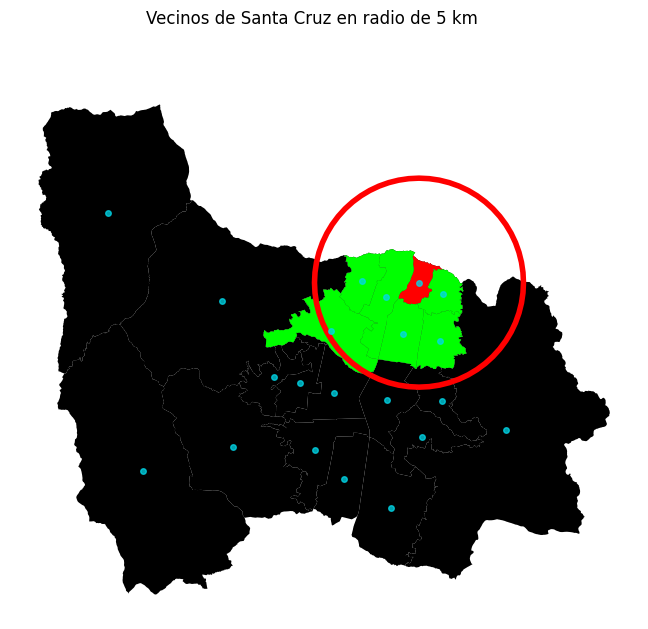

In [ ]:
f, ax = plt.subplots(1, figsize=(10, 7))

gdf_idx.plot(ax=ax, facecolor='k', linewidth=0.1)

focus = gdf_idx.loc[['SANTA CRUZ'], ['geometry']]

focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

neighbors_list = list(w_dist5km['SANTA CRUZ'])

neis = gdf_idx.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

buf = focus.centroid.buffer(5000)
buf.plot(edgecolor='red', facecolor='none', ax=ax, linewidth=4)

pts = np.array([(pt.x, pt.y) for pt in gdf_idx.centroid])
ax.plot(pts[:, 0], pts[:, 1], color='#00d8ea',
        linewidth=0, alpha=0.75, marker='o', markersize=4)

f.suptitle("Vecinos de Santa Cruz en radio de 5 km")

ax.set_axis_off()
plt.show()

####Con matriz de contiguidad

In [ ]:
gdf_idx['w_Densidad'] = weights.lag_spatial(w_queen, gdf_idx['Densidad'])
gdf_idx['w_Porc_Artificial'] = weights.lag_spatial(w_queen, gdf_idx['Porc_Artificial'])
gdf_idx['w_Porc_Qca'] = weights.lag_spatial(w_queen, gdf_idx['Porc_Qca'])
gdf_idx['w_Porc_TPu'] = weights.lag_spatial(w_queen, gdf_idx['Porc_TPu'])
gdf_idx['w_Pend_mean'] = weights.lag_spatial(w_queen, gdf_idx['Pend_mean'])
gdf_idx['w_Movimientos'] = weights.lag_spatial(w_queen, gdf_idx['Movimientos'])

In [ ]:
gdf_idx[['Movimientos', 'w_Movimientos']].head()

,Movimientos,w_Movimientos
NOMBRE,,
BELEN,165,55.600000
POPULAR,267,133.250000
ROBLEDO,100,99.714286
ARANJUEZ,106,149.142857
CASTILLA,52,97.600000


####Con Matriz de distancia

In [ ]:
gdf_idx['wd_Densidad'] = weights.lag_spatial(w_dist5km, gdf_idx['Densidad'])
gdf_idx['wd_Porc_Artificial'] = weights.lag_spatial(w_dist5km, gdf_idx['Porc_Artificial'])
gdf_idx['wd_Porc_Qca'] = weights.lag_spatial(w_dist5km, gdf_idx['Porc_Qca'])
gdf_idx['wd_Porc_TPu'] = weights.lag_spatial(w_dist5km, gdf_idx['Porc_TPu'])
gdf_idx['wd_Pend_mean'] = weights.lag_spatial(w_dist5km, gdf_idx['Pend_mean'])
gdf_idx['wd_Movimientos'] = weights.lag_spatial(w_dist5km, gdf_idx['Movimientos'])

In [ ]:
gdf_idx[['Movimientos', 'w_Movimientos']].head()

,Movimientos,w_Movimientos
NOMBRE,,
BELEN,165,55.600000
POPULAR,267,133.250000
ROBLEDO,100,99.714286
ARANJUEZ,106,149.142857
CASTILLA,52,97.600000


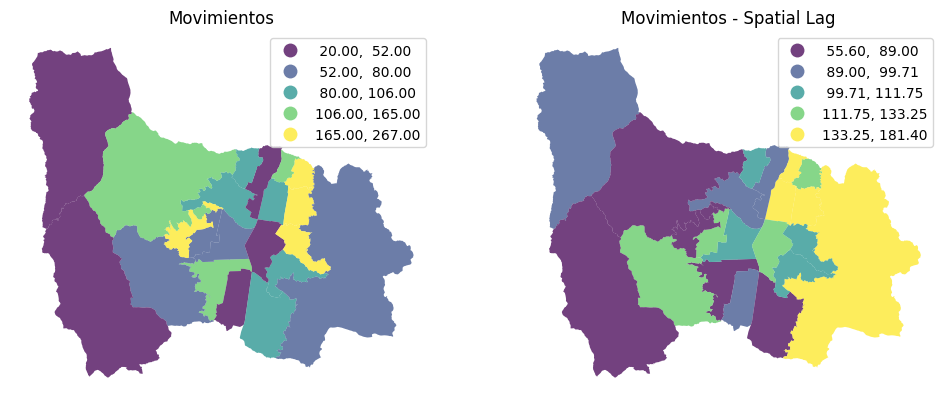

In [ ]:
f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs
gdf_idx.plot(column='Movimientos', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("Movimientos")
gdf_idx.plot(column='w_Movimientos', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("Movimientos - Spatial Lag")
plt.show()

In [ ]:
gdf_idx['Movimientos_std'] = (gdf_idx['Movimientos'] - gdf_idx['Movimientos'].mean()) / gdf_idx['Movimientos'].std()
gdf_idx['w_Movimientos_std'] = weights.lag_spatial(w_queen, gdf_idx['Movimientos_std'])

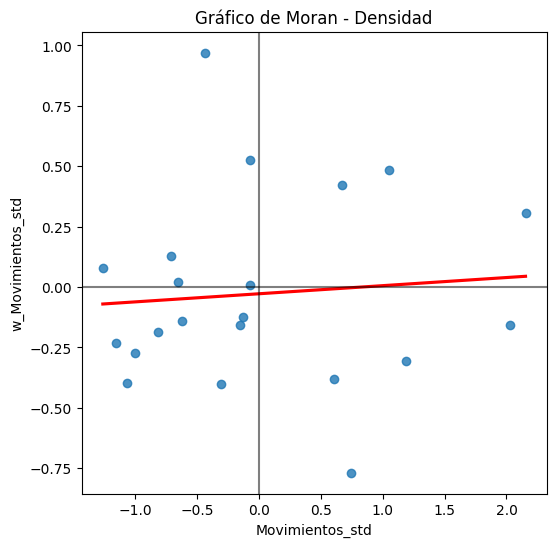

In [ ]:
import seaborn as sbn
gdf_idx['Movimientos_lag_std'] = ( gdf_idx['w_Movimientos_std'] - gdf_idx['w_Movimientos_std'].mean() )/ gdf_idx['w_Movimientos_std'].std()

f, ax = plt.subplots(1, figsize=(6, 6))
sbn.regplot(x='Movimientos_std', y='w_Movimientos_std',ci=None, data=gdf_idx, line_kws={'color':'r'})
ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)
ax.set_title('Gráfico de Moran - Densidad')
plt.show()

In [ ]:
from esda.moran import Moran

mi1 = Moran(gdf_idx['Densidad'], w_queen)
mi1.I

np.float64(0.2411634437276227)

In [ ]:
lisa1 = Moran_Local(gdf_idx['Densidad'], w_queen)

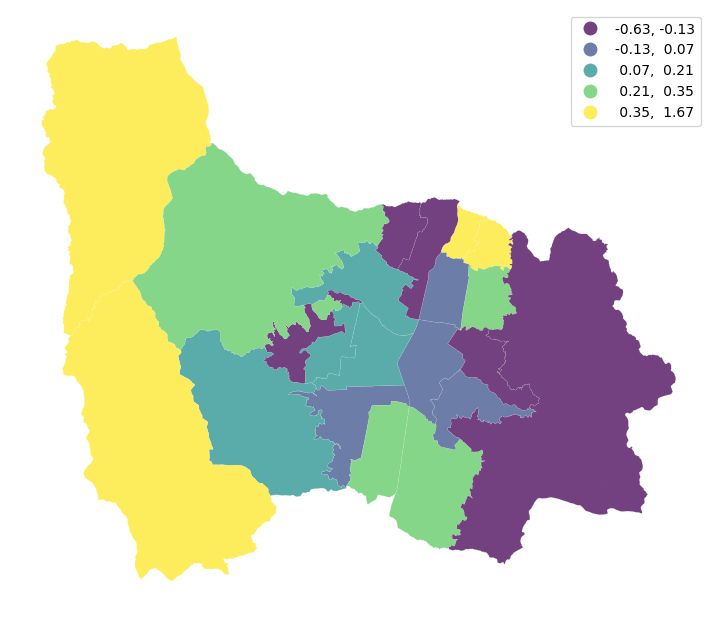

In [ ]:
f, ax = plt.subplots(1, figsize=(9,9))
gdf_idx['Is'] = lisa1.Is
gdf_idx.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

In [ ]:
gdf_idx['Movimientos_std'] = (gdf_idx['Movimientos'] - gdf_idx['Movimientos'].mean()) / gdf_idx['Movimientos'].std()
gdf_idx['wd_Movimientos_std'] = weights.lag_spatial(w_dist5km, gdf_idx['Movimientos_std'])

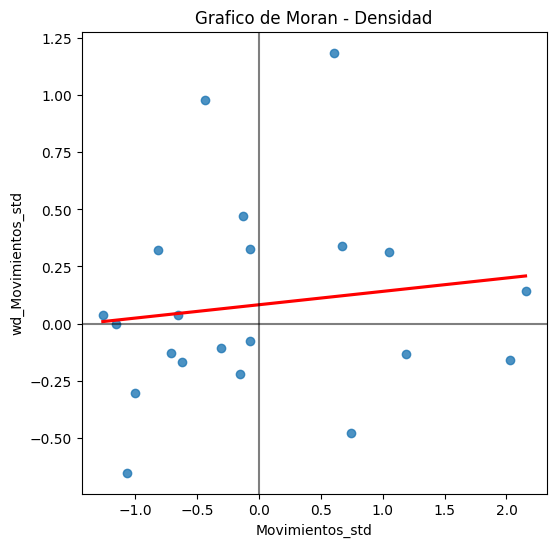

In [ ]:
import seaborn as sbn
gdf_idx['Movimientos_lagd_std'] = ( gdf_idx['wd_Movimientos_std'] - gdf_idx['wd_Movimientos_std'].mean() )/ gdf_idx['wd_Movimientos_std'].std()

f, ax = plt.subplots(1, figsize=(6, 6))
sbn.regplot(x='Movimientos_std', y='wd_Movimientos_std',ci=None, data=gdf_idx, line_kws={'color':'r'})
ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)
ax.set_title('Grafico de Moran - Densidad')
plt.show()

In [ ]:
from esda.moran import Moran

mi2 = Moran(gdf_idx['Densidad'], w_dist5km)
mi2.I

np.float64(0.14165965991302618)

In [ ]:
lisa2 = Moran_Local(gdf_idx['Densidad'], w_dist5km)

/usr/local/lib/python3.12/dist-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


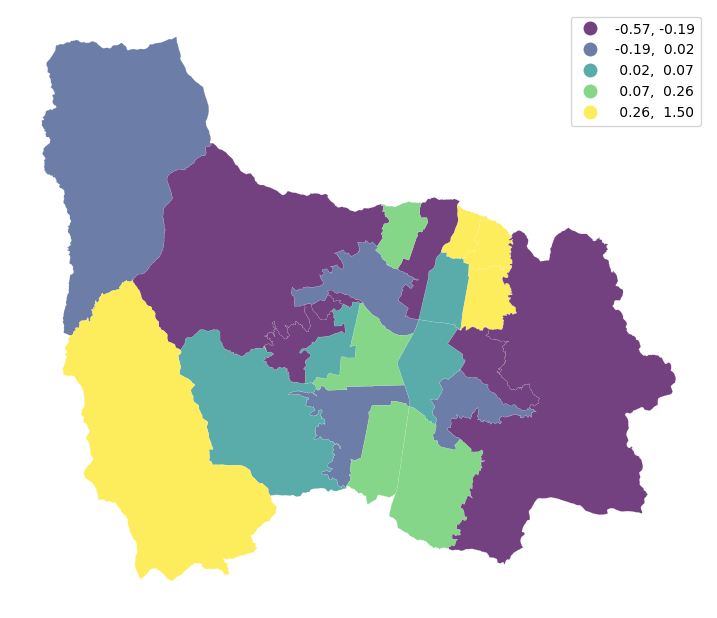

In [ ]:
f, ax = plt.subplots(1, figsize=(9,9))
gdf_idx['Is'] = lisa2.Is
gdf_idx.plot(column='Is', cmap='viridis', scheme='quantiles',k=5, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True,ax=ax);
ax.set_axis_off()

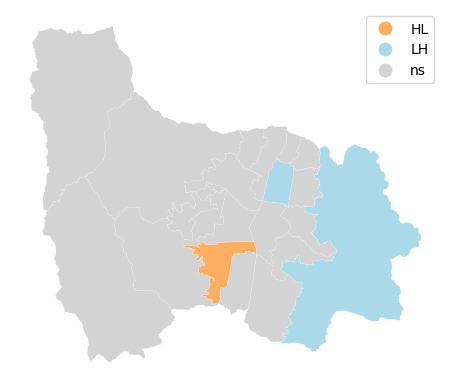

In [ ]:
from splot.esda import lisa_cluster

lisa = Moran_Local(gdf_idx["Movimientos"], w_queen)
lisa_cluster(lisa, gdf_idx);

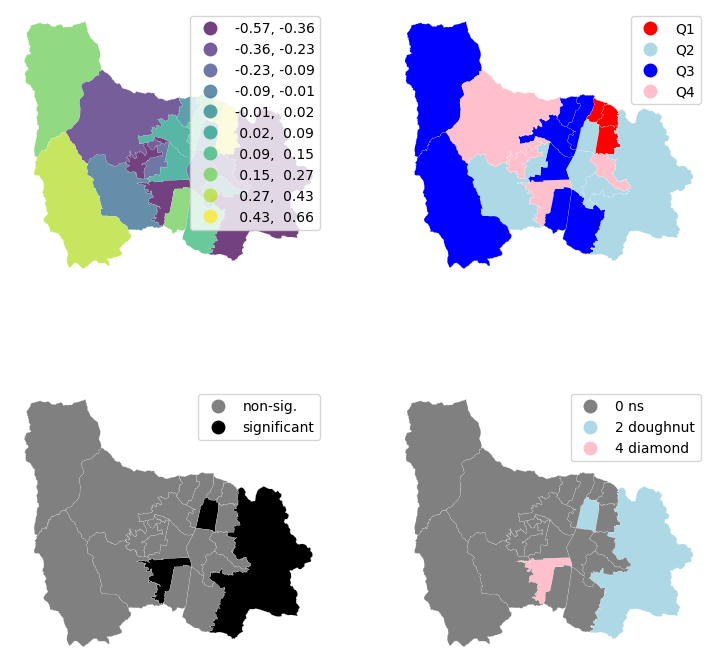

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

f, axs = plt.subplots(nrows=2, ncols=2, figsize=(9, 9))
axs = axs.flatten()

gdf_idx["Is"]=lisa.Is

# Subplot 1 #
ax = axs[0]
gdf_idx.plot(column='Is', cmap='viridis', scheme='quantiles', k=10, edgecolor='white', linewidth=0.1, alpha=0.75, legend=True, ax=ax)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 2 #
ax = axs[1]
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', 'pink'])
gdf_idx.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 3 #
ax = axs[2]
sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels = ['non-sig.', 'significant']
labels = [labels[i] for i in sig]
gdf_idx.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

# Subplot 4 #
ax = axs[3]
hotspot = 1 * (sig * lisa.q==1)
coldspot = 3 * (sig * lisa.q==3)
doughnut = 2 * (sig * lisa.q==2)
diamond = 4 * (sig * lisa.q==4)
spots = hotspot + coldspot + doughnut + diamond
spot_labels = [ '0 ns', '1 hot spot', '2 doughnut', '3 cold spot', '4 diamond']
labels = [spot_labels[i] for i in spots]
hmap = ListedColormap([ 'grey', 'red', 'lightblue', 'blue', 'pink'])
gdf.assign(cl=labels).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax,edgecolor='white', legend=True)
ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

In [ ]:
!pip install matplotlib-scalebar

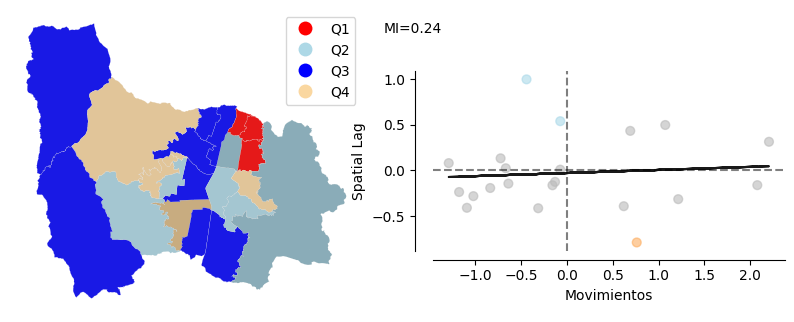

In [ ]:

from matplotlib_scalebar.scalebar import ScaleBar
from splot.esda import moran_scatterplot


f, ax = plt.subplots(nrows=1, ncols=2,figsize=(10,5))
axs = ax.flatten()

q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
labels1 = [q_labels[i-1] for i in lisa.q]
hmap = ListedColormap([ 'red', 'lightblue', 'blue', '#FAD7A0'])
gdf_idx.assign(cl=labels1).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', legend=True)

sig = 1 * (lisa.p_sim < 0.05)
hmap = ListedColormap(['grey','black'])
labels2 = ['non-sig.', 'significant']
labels2 = [labels2[i] for i in sig]
gdf_idx.assign(cl=labels2).plot(column='cl', categorical=True,k=2, cmap=hmap, linewidth=0.1, ax=ax[0],edgecolor='white', alpha=0.20)
ax[0].set_aspect('equal')
ax[0].set_axis_off()

moran_scatterplot(lisa, p=0.05,ax=ax[1])
ax[1].text(-2,1.5,f'MI={round(mi.I, 2)}')
ax[1].set_xlabel("Movimientos")
ax[1].set_title('');

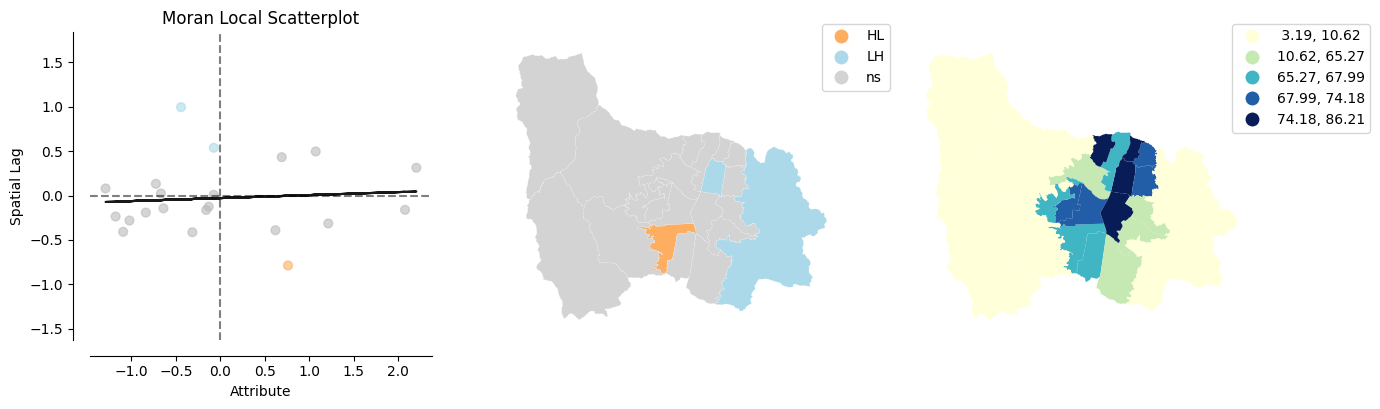

In [ ]:
from splot.esda import plot_local_autocorrelation

plot_local_autocorrelation(lisa, gdf_idx, 'Porc_Artificial');

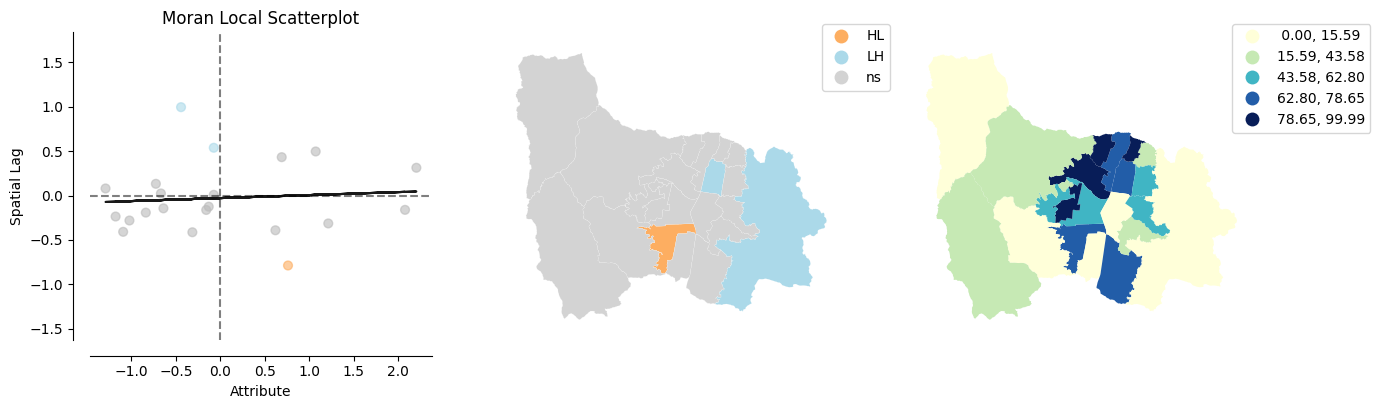

In [ ]:
from splot.esda import plot_local_autocorrelation

plot_local_autocorrelation(lisa, gdf_idx, 'Porc_Qca');

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


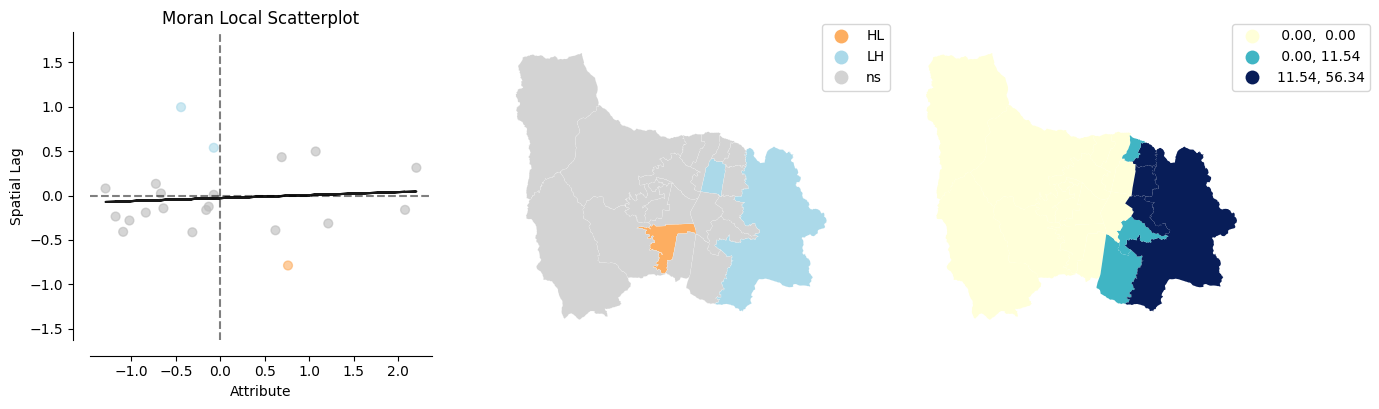

In [ ]:
from splot.esda import plot_local_autocorrelation

plot_local_autocorrelation(lisa, gdf_idx, 'Porc_TPu');

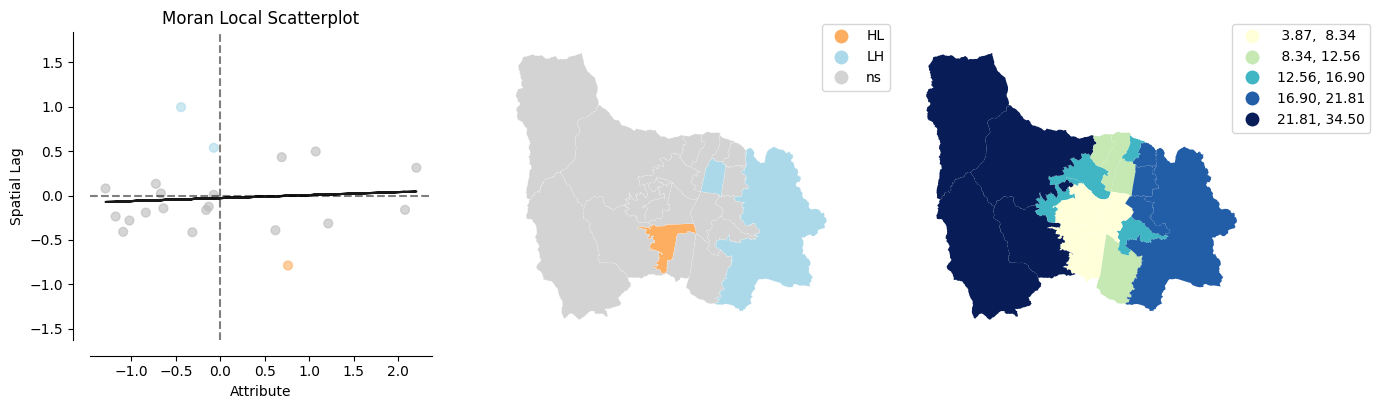

In [ ]:
from splot.esda import plot_local_autocorrelation

plot_local_autocorrelation(lisa, gdf_idx, 'Pend_mean');

#Cluster espacial

In [ ]:
from esda.moran import Moran
import numpy as np
import libpysal.weights.set_operations as Wsets
from libpysal.weights import Queen, KNN
import seaborn as sns
from pysal.lib import weights
import geopandas as gpd
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering

In [34]:
gdf.info(

)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   COMUNA           21 non-null     object  
 1   SECTOR           21 non-null     int64   
 2   NOMBRE           21 non-null     object  
 3   Shape_Leng       21 non-null     float64 
 4   Shape_Area       21 non-null     float64 
 5   geometry         21 non-null     geometry
 6   Movimientos      21 non-null     int64   
 7   Area_km2         21 non-null     float64 
 8   Densidad         21 non-null     float64 
 9   Porc_area        21 non-null     float64 
 10  Porc_mov         21 non-null     float64 
 11  I_concentracion  21 non-null     float64 
 12  Pend_mean        21 non-null     float64 
 13  Porc_Artificial  21 non-null     float64 
 14  Porc_Qca         21 non-null     float64 
 15  Porc_TPu         21 non-null     float64 
dtypes: float64(11), geometry(1), int64(2),

In [38]:
variables=["Porc_Artificial", "Porc_Qca", "Porc_TPu", "Pend_mean"]

In [39]:
kmeans5 = cluster.KMeans(n_clusters=5)
k5cls = kmeans5.fit(gdf[variables]);

In [41]:
k5cls.labels_

array([4, 3, 4, 4, 4, 2, 2, 3, 1, 1, 4, 0, 4, 0, 1, 2, 2, 1, 3, 0, 1],
      dtype=int32)

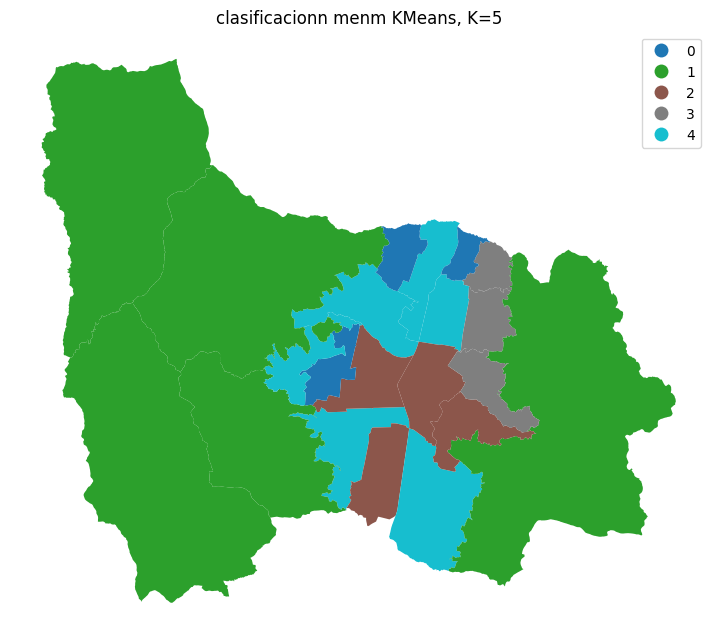

In [44]:
import matplotlib.pyplot as plt
gdf['var'] = k5cls.labels_
# Setup figure and ax
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot unique values choropleth including a legend and with no boundary lines
gdf.plot(column='var', categorical=True, legend=True, linewidth=0, ax=ax)
# Remove axis
ax.set_axis_off()
# Add title
plt.title('clasificacionn menm KMeans, K=5')
# Display the map
plt.show()